In [1]:
# MANTENIEMIENTO PREVENTIVO Y PREDICTIVO 
#DESCRIPCIÓN: Tomar datos de los sensores de las celdas MT y Transformadores Ormazabal 
#OBJETIVOS: Lograr predecir eventos anomalos antes de que sucedan Modelo de aprendizaje automatico Modeloestatico para predecir avería 
#APLICACION: para celdas MT verificar fallaerror averia por Machine Learnig

In [17]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd


In [18]:
df = pd. read_csv("C:/Users/Cristina/Documents/E1/ai4i2020.csv")
df.head()



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [19]:
#revisar si faltan datos 
# Acceder a la columna por nombre

# Conteo de valores nulos en toda la tabla
df.isnull().sum()



UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [20]:
#para ver conjunto de datos vemos desviacion estandar min - max 
df. describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

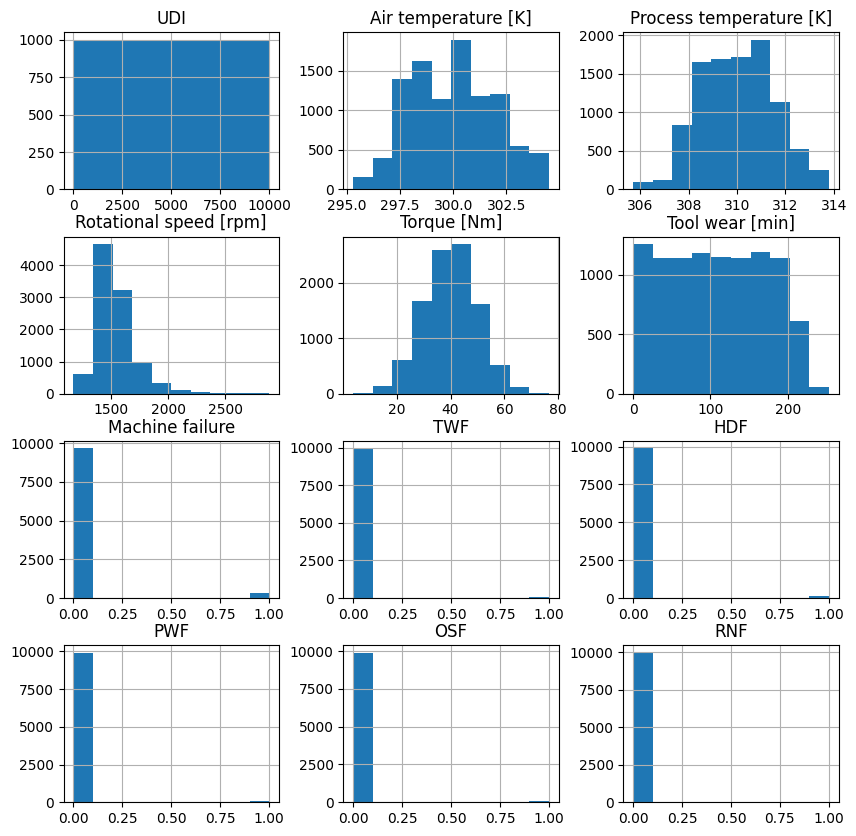

In [21]:
#realizar la 1º grafica de los datos 
df.hist(figsize=(10,10))

#desestimar la figura 1 UDI

In [22]:
#distribucion de clases      # define un arreglo

df["Machine failure"]. unique() 
# 0 =no fallo   1= fallo 


array([0, 1])

In [23]:
# contador de valores
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

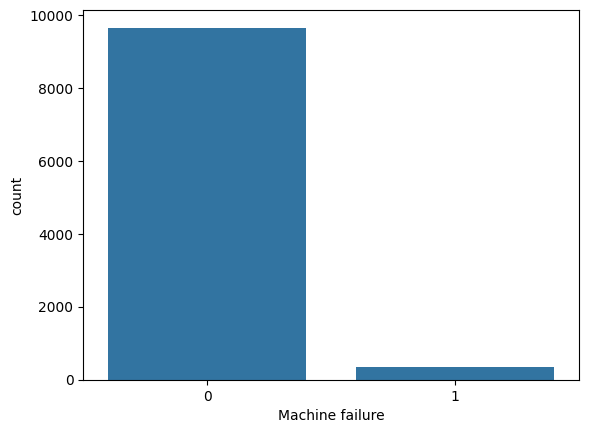

In [24]:
# recuento de puntos 
sns.countplot(x="Machine failure", data=df)
#vemos que el fallo es muy pequeño en comparacion con el no fallo 

In [25]:
#tipo clase de relleno, consjunto de datos 
# tipos de fallo:  'TWF', 'HDF', 'PWF', 'OSF','RNF'
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [26]:
#columnas de relleno 
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve exactamente el nombre de la falla
    return "No Failure"  # usa la misma etiqueta que el dataset original

df["Failure Type"] = df.apply(classify_failure_type, axis=1)



In [27]:
#aplicar columna en el eje X
def classify_failure_type(row):
    if row["Machine failure"] == 1:
        return "Fallo detectado"
    else:
        return "Sin fallo"

df["Failure Type"] =df.apply(classify_failure_type, axis=1)


In [28]:
#veriricar 
df["Failure Type"]

0       Sin fallo
1       Sin fallo
2       Sin fallo
3       Sin fallo
4       Sin fallo
          ...    
9995    Sin fallo
9996    Sin fallo
9997    Sin fallo
9998    Sin fallo
9999    Sin fallo
Name: Failure Type, Length: 10000, dtype: str

#### tenemos que instruir a la IA a que tenga un activo automatico para poder predecir perfectamente la falla
#### nunca se espera que la maquina falle

<Axes: xlabel='Failure Type', ylabel='count'>

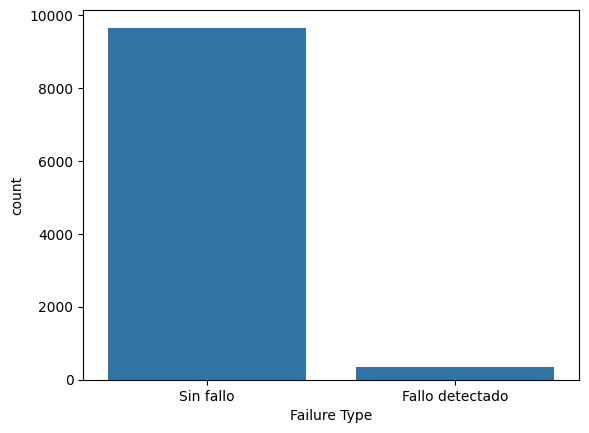

In [29]:
#trazado de cuentas 
sns.countplot(x="Failure Type", data=df)

<Axes: xlabel='Type', ylabel='count'>

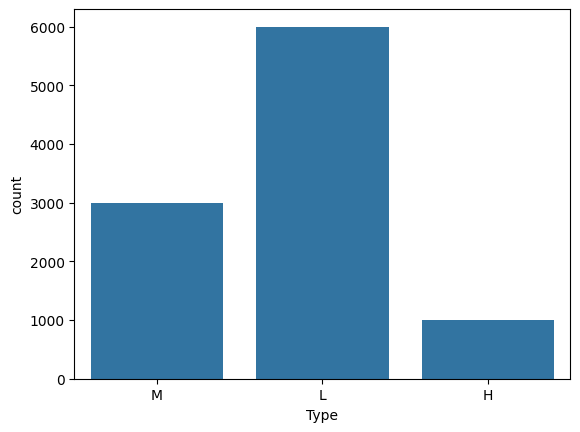

In [30]:
 
import seaborn as sns
import matplotlib.pyplot as plt
# equilibrar las tablas
sns.countplot(x='Type', data=df)

In [31]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def classify_failure_type(row):
    for col in failure_cols:
        if row[col] == 1:
            return col   # devuelve exactamente el nombre de la falla
    return "No Failure"  # usa la misma etiqueta que el dataset original

df ["Failure Type"] = df.apply(classify_failure_type, axis=1)


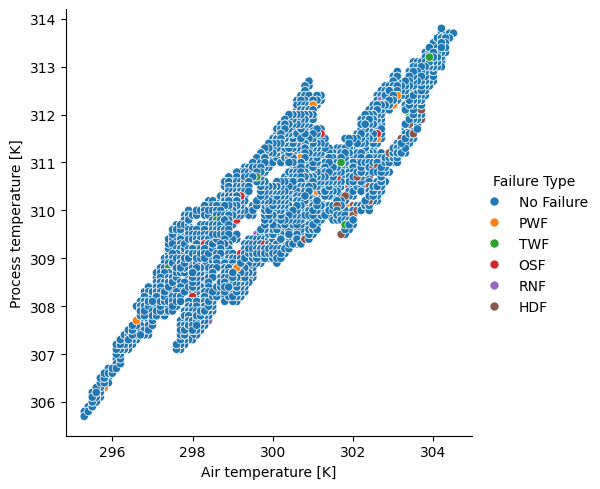

In [33]:


#graficar seaborn # grafico de tempartura 
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Failure Type",      # cada categoría con un color distinto
    sizes=(100, 50),          # tamaño de los puntos fijo
    data=df
)

plt.show()



# sirve para trasar la temperaatura de la grasa que tiene en motor con respecto a la grasa uqe tenemos, pero si lo consideramos puede servir para checar la temperatura del aceite de un Transformador.
#tambien la funcion valdra para saber evaluar la temperatura del aire de las celdas o Transformadores si es que este operara con aire en vez de aceite. 
#ver la nomenclarura con la que se llenan la temperatura del proceso.
#GRAFICO DE DISPERSION 


In [34]:
df["Failure Type"].unique()  #esto verifica que se valida la columna de errores
# en los colores apuntan a fallos por ejemplo PWF corte de energia 

<StringArray>
['No Failure', 'PWF', 'TWF', 'OSF', 'RNF', 'HDF']
Length: 6, dtype: str

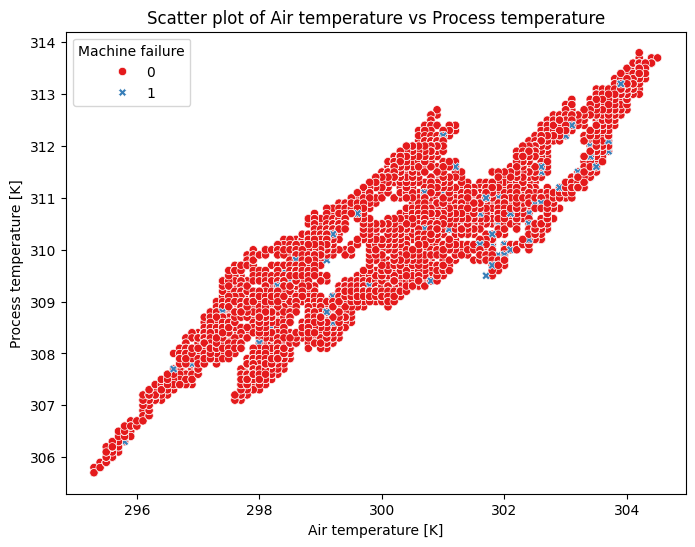

In [35]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Air temperature [K]",
    y="Process temperature [K]",
    hue="Machine failure",
    style="Machine failure",
    palette="Set1",   
    data=df
)
plt.title("Scatter plot of Air temperature vs Process temperature")
plt.show()
# cuando se enfrentan los datos sale en fallo de maquina. velocidad y par motor 

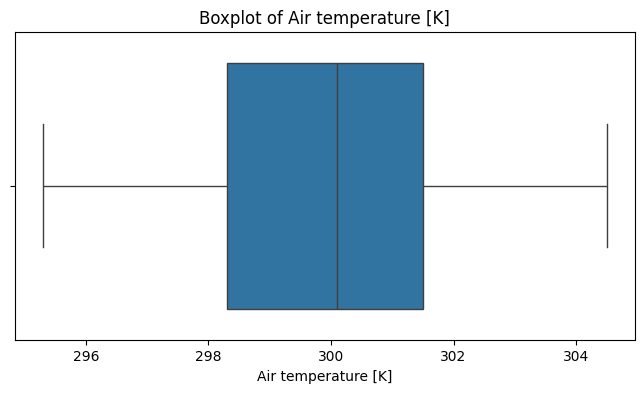

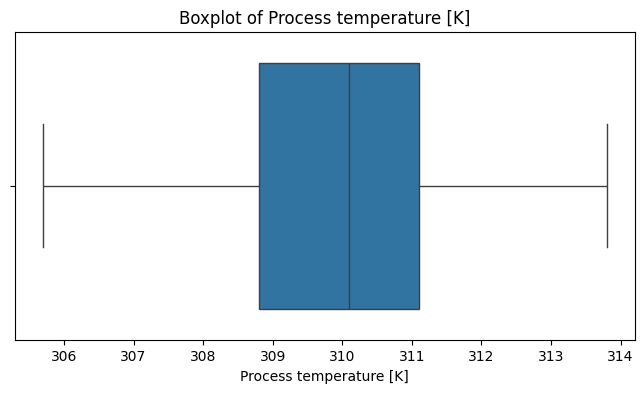

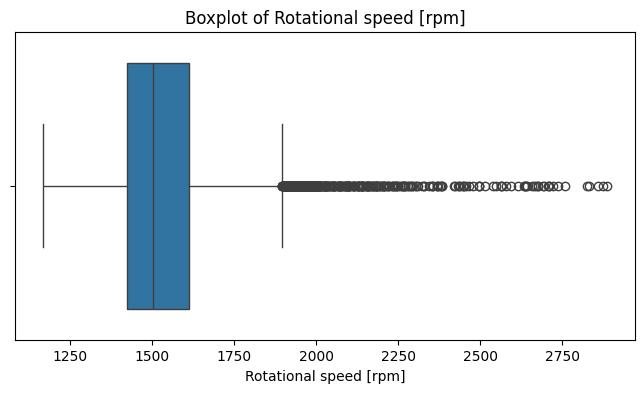

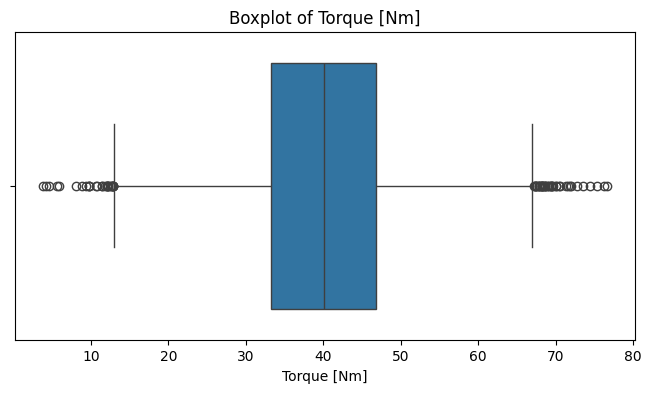

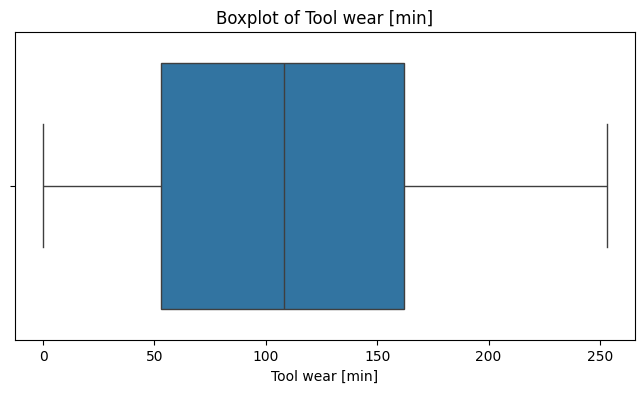

In [36]:
#deteccion de fallos de los sensores
#la mayoria dentro de los rangos normales de funcionamiento
#pero la de rotacion tiene valores anomalos 
#torque tambien tiene valores atipicos 
sensor_cols = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for col in sensor_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


###  intuimos que la rotacion esta la falla 
+ El par (torque) and la velocidad de rotación tuvieron más valores atípicos or puntos fuera de sus range normal de cuartiles.
 Explicación rápida para clase:
  Torque = fuerza de giro.
  Rotational speed = velocidad de rotación.
  Outliers = valores atípicos, puntos que se alejan mucho de la distribución normal.
Quartiles = divisiones estadísticas que separan los datos en cuatro partes.


### ingenieria de caracteristica y aprendizaje AUTOOMATICO 



#OBTENER LAS COLUMNAS QUE NECESITAMOS



In [37]:
df.columns 


Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure Type'],
      dtype='str')

In [38]:
df['Type']. unique()



<StringArray>
['M', 'L', 'H']
Length: 3, dtype: str

In [39]:
# codificacion simple 
df['Type_num'] = df['Type'].map({'L':0, 'M':1, 'H':2})



In [40]:
# Selección de columnas de características (features)
feature_cols = ['Type_num', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Xfeatures = df[feature_cols]


# Selección de la columna objetivo (labels)  #se puede usar para hacer binario normal 
ylabels = df['Machine failure']
# dividimos el conjunto de datos 

In [41]:
# Cargar paquetes de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression


### Explicación paso a paso
train_test_split

Sirve para dividir tu dataset en conjunto de entrenamiento y conjunto de prueba.

Ejemplo: entrenas el modelo con el 70% de los datos y lo pruebas con el 30% restante.

RandomForestClassifier

Algoritmo de clasificación basado en bosques aleatorios (muchos árboles de decisión combinados).

Es robusto y maneja bien datasets con muchas variables.

classification_report

Genera un informe con métricas como precisión, recall y F1-score para evaluar el rendimiento del modelo.

confusion_matrix y ConfusionMatrixDisplay

La matriz de confusión muestra cuántos casos fueron clasificados correctamente y cuántos se confundieron entre clases.

ConfusionMatrixDisplay permite graficar esa matriz de manera visual.

LogisticRegression

Modelo clásico de clasificación binaria (fallo vs. no fallo).

Útil para comparar con Random Forest y ver cuál se ajusta mejor a tus datos.

In [42]:
# Split (división de datos en entrenamiento y prueba)
# Codificar la columna Type
df['Type_num'] = df['Type'].map({'L':0, 'M':1, 'H':2})

# Features y labels
feature_cols = ['Type_num', 'Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Xfeatures = df[feature_cols]
ylabels = df['Machine failure']



### En esa celda de abajo defini una función auxiliar build_model que encapsula el entrenamiento y la evaluación del clasificador.

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def build_model(classifier, x_train, y_train, x_test, y_test):
    classifier.fit(x_train, y_train)
    y_pred = classifier.predict(x_test)
    print("Accuracy:", classifier.score(x_test, y_test))
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    return classifier


In [44]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.25, random_state=42)

# Modelo Random Forest ESTADO ALEATORIO
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf = rf.fit(X_train, y_train)

In [45]:
# Precisión
print("Accuracy (Random Forest):", rf_clf.score(X_test, y_test))

# Modelo de Regresión Logística (opcional)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
print("Accuracy (Logistic Regression):", log_reg.score(X_test, y_test))


Accuracy (Random Forest): 0.9864
Accuracy (Logistic Regression): 0.9752


### antes evaluacion del modelo

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# Features y labels
Xfeatures = df[feature_cols]
ylabels = df['Machine failure']

# Split# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.25, random_state=42)


# Entrenar modelo
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones
y_pred = rf_clf.predict(X_test)

# Informe de clasificación
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2428
           1       0.88      0.61      0.72        72

    accuracy                           0.99      2500
   macro avg       0.93      0.80      0.86      2500
weighted avg       0.99      0.99      0.99      2500



##### hay que notar que tenemos los valores perfectos como habiamos nombradoactivo para equilibrar fallo

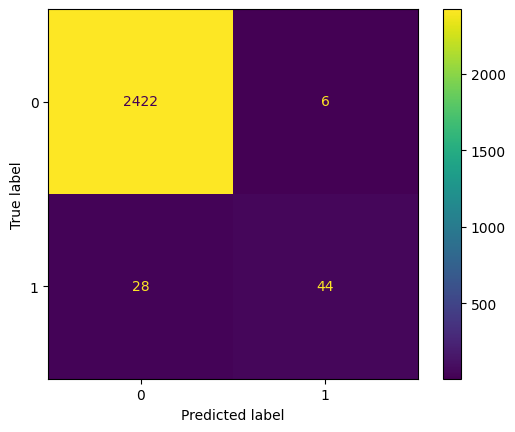

In [49]:
cm=confusion_matrix(y_test, y_pred,labels= rf_clf.classes_)
disp= ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot()
plt.show()

### 0=no fallo 1=fallo la cantidada de veces de predecir fallos  

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


# Features y labels
Xfeatures = df[feature_cols]
ylabels = df['Machine failure']

# Split# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(Xfeatures, ylabels, test_size=0.25, random_state=42)


# Entrenar modelo
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones
y_pred = rf_clf.predict(X_test)

# Informe de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2428
           1       0.88      0.61      0.72        72

    accuracy                           0.99      2500
   macro avg       0.93      0.80      0.86      2500
weighted avg       0.99      0.99      0.99      2500



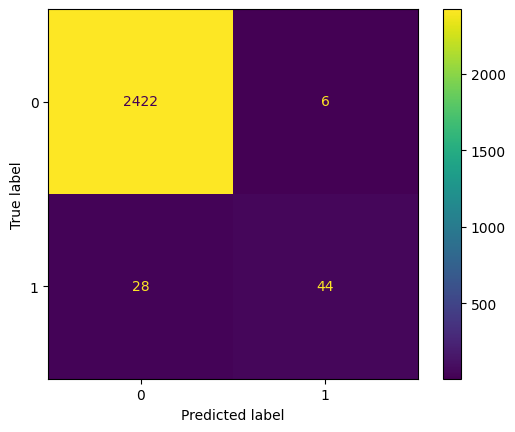

In [57]:
cm=confusion_matrix(y_test, y_pred,labels= rf_clf.classes_)
disp= ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot()
plt.show()

vamos hacer una prueba antes prediccion simple para un elemento

In [ ]:
# 8. Predicción de una muestra individual (Estructura corregida)
# Selecciona la primera fila del conjunto de prueba como una muestra  el 0 puede variar por el valor que necesitemos 
sample_data = X_test.iloc[[0]] 

# Realiza la predicción usando tu modelo Random Forest (rf)
rf_prediction = rf.predict(sample_data)

print(f"Muestra a evaluar (Fila 0 de X_test):")
print(sample_data)
print("-" * 30)
print("RF Prediction:", rf_prediction[0])


Muestra a evaluar (Fila 0 de X_test):
      Type_num  Air temperature [K]  Process temperature [K]  \
6252         0                300.8                    310.3   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
6252                    1538         36.1              198  
------------------------------
RF Prediction: 0


##### hay que notar que nosotros pudimos optar por poner en un principio LogisticRegression (lr = LogisticRegression()). pero optamos por RandomForestClassifier.

CON ESTE BLOQUE VOLVEMOS A ENSEÑAR ANUESTRA MATRIZ DE CONFUSION 

In [63]:
# 1. Extrae la primera fila de forma bidimensional
sample_data = X_test.iloc[[0]]

# 2. Predicción con tu Random Forest activo (usa rf_clf o rf según cómo lo llamaste antes)
rf_prediction = rf_clf.predict(sample_data)
print("RF prediction:", rf_prediction)


RF prediction: [0]


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2428
           1       0.86      0.43      0.57        72

    accuracy                           0.98      2500
   macro avg       0.92      0.71      0.78      2500
weighted avg       0.98      0.98      0.98      2500

--------------------------------------------------
RF prediction para la primera muestra: [0]
--------------------------------------------------


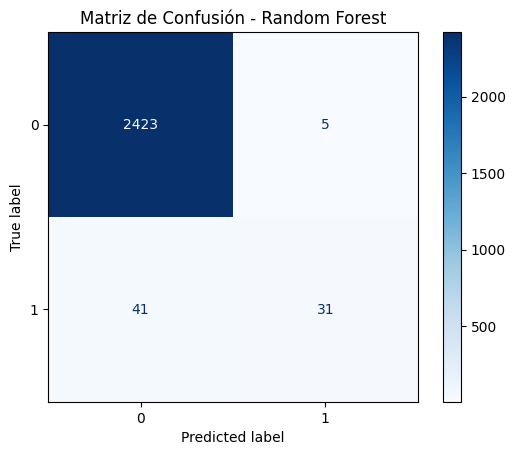

In [64]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Características y etiquetas
Xfeatures = df[feature_cols]
ylabels = df["Machine failure"]

# 2. Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    Xfeatures, ylabels, test_size=0.25, random_state=42
)

# 3. Inicializar y entrenar el modelo (Asegúrate de usar class_weight para nivelar errores)
rf_clf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Predicciones globales e informe métrico
y_pred = rf_clf.predict(X_test)
print("Informe de Clasificación:")
print(classification_report(y_test, y_pred))
print("-" * 50)

# 5. Código corregido para la muestra individual (Consistente con 'rf_clf')
sample_data = X_test.iloc[[0]]
rf_prediction = rf_clf.predict(sample_data)  # <-- Aquí se corrigió de 'rf' a 'rf_clf'
print("RF prediction para la primera muestra:", rf_prediction)
print("-" * 50)

# 6. Matriz de confusión solicitada
cm = confusion_matrix(y_test, y_pred, labels=rf_clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_clf.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()


In [69]:
import eli5

In [71]:
eli5.show_weights(rf_clf, feature_names=Xfeatures.columns.tolist())

Weight,Feature
0.3067 ± 0.2510,Rotational speed [rpm]
0.3044 ± 0.2549,Torque [Nm]
0.2108 ± 0.0716,Tool wear [min]
0.0986 ± 0.0743,Air temperature [K]
0.0659 ± 0.0464,Process temperature [K]
0.0136 ± 0.0138,Type_num
